# Parkinsons Telemonitoring: Regularized Linear Regression

In [1]:
import pandas as pd

# the .data file is plain comma-separated text with a header row
df = pd.read_csv("data/parkinsons_updrs.data")
df.shape

(5875, 22)

In [2]:
# 5,875 recordings from 42 people, so rows are repeated measurements
df.info()
print("distinct participants:", df["subject#"].nunique())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR            5875

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


## Ridge regression setup

In [3]:
import numpy as np

TARGETS = ["motor_UPDRS", "total_UPDRS"]
ALPHA_GRID = np.logspace(-3, 3, 25)
TEST_SIZE = 0.2
N_FOLDS = 5
RANDOM_STATE = 42

In [4]:
from sklearn.model_selection import train_test_split

# one shared split keeps both outcomes' test sets comparable
# recordings are split randomly, so participants appear in both halves
train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
len(train_idx), len(test_idx)

(4700, 1175)

In [5]:
# the unused UPDRS column is the target's near-duplicate, so it stays out of X
feature_cols = list(df.columns[6:])
assert len(feature_cols) == 16
feature_cols

['Jitter(%)',
 'Jitter(Abs)',
 'Jitter:RAP',
 'Jitter:PPQ5',
 'Jitter:DDP',
 'Shimmer',
 'Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'Shimmer:APQ11',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'RPDE',
 'DFA',
 'PPE']

## Tuning and holdout results

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

results = {}
for target in TARGETS:
    y_train = df.loc[train_idx, target]
    y_test = df.loc[test_idx, target]

    # scaling inside the pipeline keeps StandardScaler fit on training folds only
    # ridge penalizes coefficients, so predictors must share one scale
    pipe = Pipeline([("scale", StandardScaler()), ("ridge", Ridge())])
    search = GridSearchCV(pipe, {"ridge__alpha": ALPHA_GRID}, cv=N_FOLDS)
    search.fit(df.loc[train_idx, feature_cols], y_train)

    pred = search.predict(df.loc[test_idx, feature_cols])
    # predicting the training mean is the no-skill RMSE reference
    mean_pred = [y_train.mean()] * len(y_test)

    print(target)
    print("  best alpha:     ", search.best_params_["ridge__alpha"])
    print("  best CV R2:     ", round(search.best_score_, 3))
    print("  holdout R2:     ", round(r2_score(y_test, pred), 3))
    print("  holdout RMSE:   ", round(root_mean_squared_error(y_test, pred), 3))
    print("  mean-only RMSE: ", round(root_mean_squared_error(y_test, mean_pred), 3))
    print("  holdout MAE:    ", round(mean_absolute_error(y_test, pred), 3))

    results[target] = {"search": search, "y_test": y_test, "pred": pred}

motor_UPDRS
  best alpha:      56.23413251903491
  best CV R2:      0.108
  holdout R2:      0.076
  holdout RMSE:    7.682
  mean-only RMSE:  7.991
  holdout MAE:     6.566


total_UPDRS
  best alpha:      56.23413251903491
  best CV R2:      0.1
  holdout R2:      0.08
  holdout RMSE:    10.096
  mean-only RMSE:  10.531
  holdout MAE:     8.3


## Plots

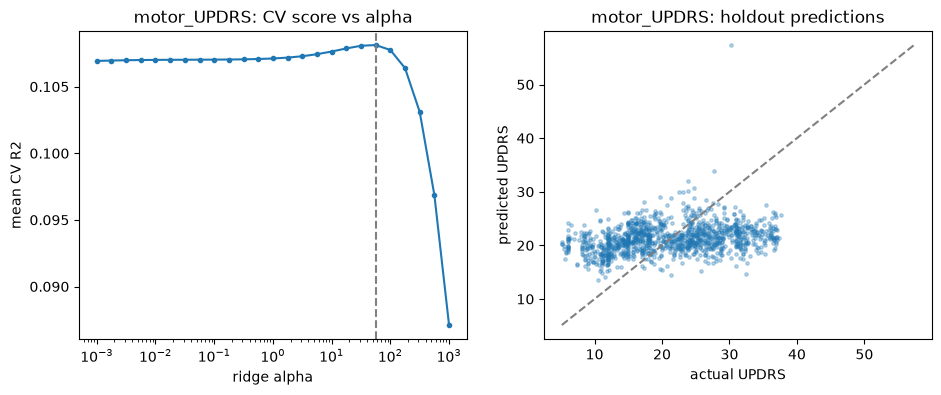

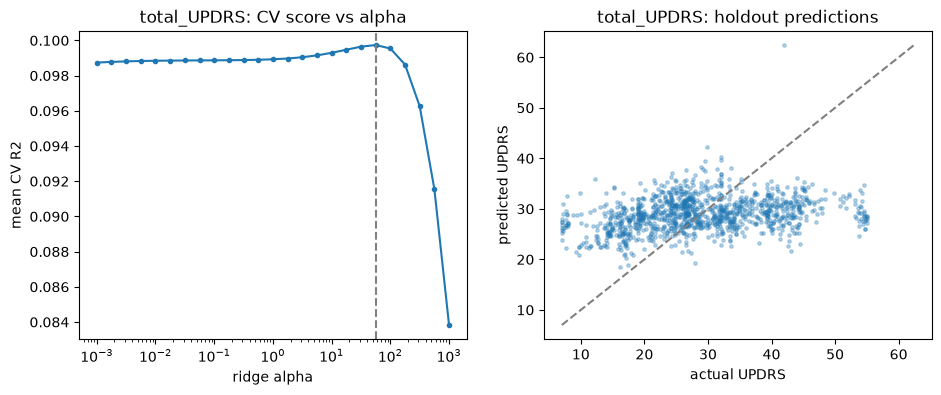

In [7]:
import matplotlib.pyplot as plt

for target, res in results.items():
    search = res["search"]
    alphas = search.cv_results_["param_ridge__alpha"].data.astype(float)
    mean_cv = search.cv_results_["mean_test_score"]

    fig, (ax_curve, ax_scatter) = plt.subplots(1, 2, figsize=(11, 4))

    # weak penalty overfits the folds, strong penalty flattens toward zero
    ax_curve.plot(alphas, mean_cv, marker=".")
    ax_curve.set_xscale("log")
    ax_curve.axvline(search.best_params_["ridge__alpha"], color="gray", linestyle="--")
    ax_curve.set_xlabel("ridge alpha")
    ax_curve.set_ylabel("mean CV R2")
    ax_curve.set_title(f"{target}: CV score vs alpha")

    ax_scatter.scatter(res["y_test"], res["pred"], s=6, alpha=0.3)
    lims = [
        min(res["y_test"].min(), res["pred"].min()),
        max(res["y_test"].max(), res["pred"].max()),
    ]
    ax_scatter.plot(lims, lims, color="gray", linestyle="--")
    ax_scatter.set_xlabel("actual UPDRS")
    ax_scatter.set_ylabel("predicted UPDRS")
    ax_scatter.set_title(f"{target}: holdout predictions")

plt.show()